# **CUDA & GPU Concept**

1 thread = 1 eksekusi kecil
1 block = kumpulan thread
grid = kumpulan block

In [1]:
# Setup PyCUDA (Colab / Linux)
!pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 30.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 13.0 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp312-cp312-linux_x86_64.whl size=659447 sha256=a998fd929933daa81b63359d4409c7f2dd88ff86f2bd32ca6077ce7f0610267a
  Stored in directory: /root/.cache/pip/wheels/90/2a/71/75ec0cc316cc0ff494bfffa2935e02580129cb7f859a0cfd8f
Successfully built pycuda


In [2]:
#Cek GPU
!nvidia-smi

Thu Jun 11 00:27:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# **Vector Addition (PyCUDA Basic)**

In [4]:
# CPU Vector Addition (Baseline)
import numpy as np
import time

def cpu_vector_add(a, b):
    start = time.time()
    c = a + b
    end = time.time()
    return c, (end - start)

sizes = [10**4, 10**5, 10**6, 5*10**6]

cpu_times = []

for n in sizes:
    a = np.random.rand(n).astype(np.float32)
    b = np.random.rand(n).astype(np.float32)

    _, t = cpu_vector_add(a, b)
    cpu_times.append(t)

    print(f"CPU size {n}: {t:.6f} sec")

CPU size 10000: 0.000029 sec
CPU size 100000: 0.000064 sec
CPU size 1000000: 0.000644 sec
CPU size 5000000: 0.006163 sec


In [5]:
# GPU Vector Addition (PyCUDA)
import pycuda.autoinit
import pycuda.driver as cuda
import numpy as np
from pycuda.compiler import SourceModule
import time

#CUDA Kernel
mod = SourceModule("""
__global__ void add(float *a, float *b, float *c)
{
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    c[idx] = a[idx] + b[idx];
}
""")

func = mod.get_function("add")


In [7]:
# GPU Function Benchmark
def gpu_vector_add(a, b):
    n = a.size
    c = np.zeros_like(a)

    start = cuda.Event()
    end = cuda.Event()

    a_gpu = cuda.mem_alloc(a.nbytes)
    b_gpu = cuda.mem_alloc(b.nbytes)
    c_gpu = cuda.mem_alloc(c.nbytes)

    cuda.memcpy_htod(a_gpu, a)
    cuda.memcpy_htod(b_gpu, b)

    block_size = 256
    grid_size = (n + block_size - 1) // block_size

    start.record()

    func(a_gpu, b_gpu, c_gpu,
         block=(block_size,1,1),
         grid=(grid_size,1))

    end.record()
    end.synchronize()

    cuda.memcpy_dtoh(c, c_gpu)

    gpu_time = start.time_till(end) / 1000  # ms → sec

    return c, gpu_time

In [8]:
# Run GPU Benchmark

gpu_times = []

for n in sizes:
    a = np.random.rand(n).astype(np.float32)
    b = np.random.rand(n).astype(np.float32)

    _, t = gpu_vector_add(a, b)
    gpu_times.append(t)

    print(f"GPU size {n}: {t:.6f} sec")

GPU size 10000: 0.000090 sec
GPU size 100000: 0.000015 sec
GPU size 1000000: 0.000048 sec
GPU size 5000000: 0.000239 sec


# **Visualisasi Perbandingan (CPU vs GPU)**

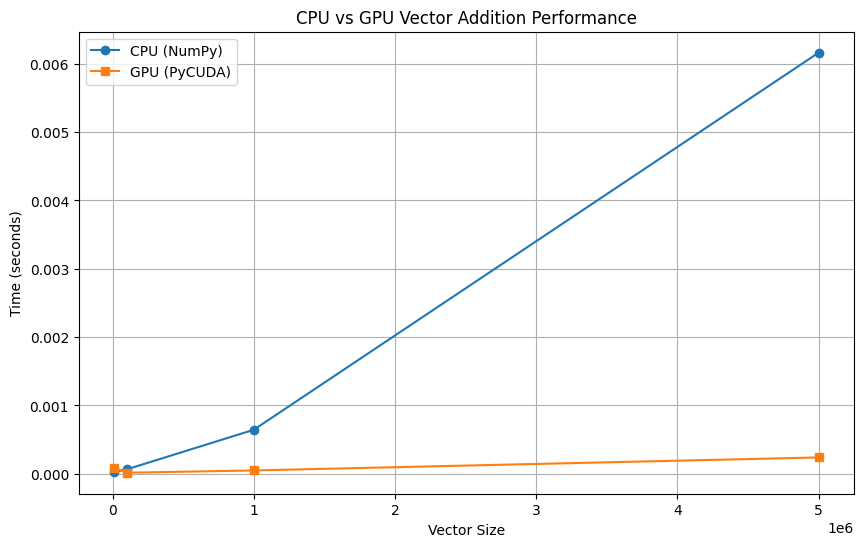

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(sizes, cpu_times, marker='o', label='CPU (NumPy)')
plt.plot(sizes, gpu_times, marker='s', label='GPU (PyCUDA)')

plt.xlabel("Vector Size")
plt.ylabel("Time (seconds)")
plt.title("CPU vs GPU Vector Addition Performance")
plt.legend()
plt.grid(True)
plt.show()

# **Visualisasi Speedup (GPU advantage)**

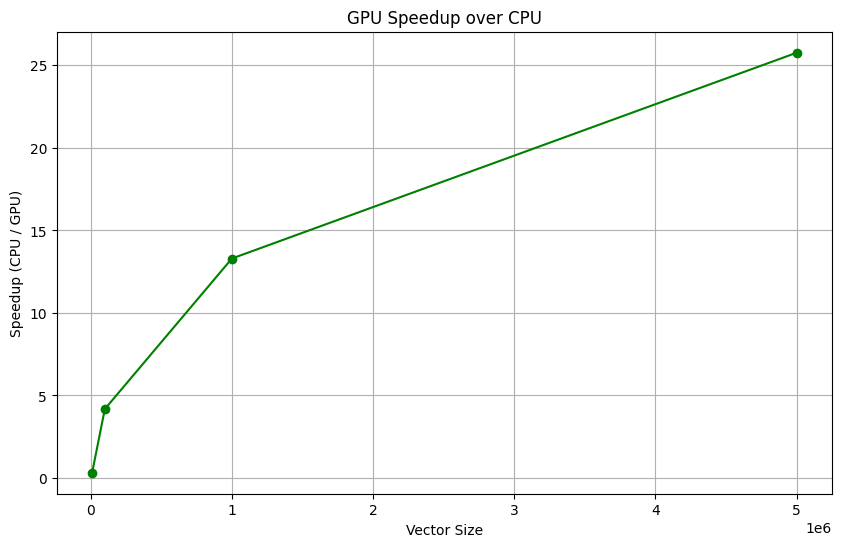

In [10]:
speedup = [c/g for c, g in zip(cpu_times, gpu_times)]

plt.figure(figsize=(10,6))

plt.plot(sizes, speedup, marker='o', color='green')
plt.xlabel("Vector Size")
plt.ylabel("Speedup (CPU / GPU)")
plt.title("GPU Speedup over CPU")
plt.grid(True)
plt.show()